Or Buganim 207944976

## Section 2: Dataset Selection

### 2.1 Requirements Verification
* **Tabular Data:** Yes, the dataset is tabular.
* **Size:** Contains over 1000 rows (2111 rows) and at least 10 columns (17 columns).
* **Variable Types:** Includes a mix of numerical, categorical, and ordinal variables.

### 2.2 Data Source Description
* **Source:** The dataset is "Estimation of obesity levels based on eating habits and physical condition", originally published on the UCI Machine Learning Repository.
* **Purpose of Collection:** The data was collected to estimate obesity levels in individuals from the countries of Mexico, Peru, and Colombia, based on their eating habits and physical condition. 
* **Data Collector:** The data was collected and synthetically expanded by researchers (Pale Chorres et al.) for academic and predictive modeling purposes.
* **Domain Knowledge Connection:** Understanding the relationship between lifestyle choices (e.g., frequency of high-caloric food consumption, physical activity, transportation mode) and obesity levels is crucial for public health and preventive medicine.

In [1]:
import pandas as pd
import numpy as np

# Load the CSV file into a DataFrame
file_path = "ObesityDataSet_raw_and_data_sinthetic.csv"
df = pd.read_csv(file_path)

# Display the first 5 rows to verify successful loading
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## Section 3: Meta-Analysis of the Data

### 3.1 File Analysis
* **Format:** CSV (Comma-Separated Values).
* **Creation Date:** The original dataset was published around 2019.
* **Purpose of Data:** To analyze, understand, and predict obesity risk levels based on physiological attributes and daily lifestyle habits.

In [2]:
import os

# Calculate and print the file size
file_size_kb = os.path.getsize("ObesityDataSet_raw_and_data_sinthetic.csv") / 1024
print(f"File Size: {file_size_kb:.2f} KB\n")

# Display Data Structure: Number of rows and columns
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}\n")

# Display column names and their respective data types
print("Column Names and Data Types:")
print(df.dtypes)

File Size: 257.47 KB

Number of Rows: 2111
Number of Columns: 17

Column Names and Data Types:
Age                               float64
Gender                                str
Height                            float64
Weight                            float64
CALC                                  str
FAVC                                  str
FCVC                              float64
NCP                               float64
SCC                                   str
SMOKE                                 str
CH2O                              float64
family_history_with_overweight        str
FAF                               float64
TUE                               float64
CAEC                                  str
MTRANS                                str
NObeyesdad                            str
dtype: object


### 3.2 Data Structure Insights & Discussion

* **Column Names Meaningfulness:** The column names are a mix of clear, intuitive descriptions (e.g., `Age`, `Gender`, `Height`, `Weight`) and specific acronyms (e.g., `FCVC`, `NCP`, `CH2O`, `FAF`). The acronyms imply that domain experts structured the data. While they require a data dictionary to be fully understood by an outsider, they make perfect sense in a medical or nutritional context.
* **Data Types Insight:** The data types align well with expectations. Continuous numerical variables (`Age`, `Height`, `Weight`) are correctly formatted as `float64`, while categorical and ordinal lifestyle variables (`Gender`, `SMOKE`, `MTRANS`, `NObeyesdad`) are loaded as `object` (strings). 
* **Research vs. Operations:** This dataset was clearly collected and compiled for **research** purposes (specifically, machine learning classification), rather than for ongoing operational or clinical logging.
* **Potential Biases:**
    1. **Selection & Geographical Bias:** The data originates from individuals in Mexico, Peru, and Colombia. Consequently, the dietary habits (like frequent consumption of high-caloric food) and genetic predispositions represent a specific population and might not accurately generalize to a global scale.
    2. **Synthetic Data Bias:** As indicated by the file name (`_sinthetic`), the dataset contains synthetically generated records (likely using SMOTE) to balance the target classes. While this improves model training, it introduces artificial patterns that do not represent real human measurements.

In [3]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values[missing_values > 0])

# Check for exact duplicate rows
duplicates_count = df.duplicated().sum()
print(f"\nNumber of full duplicate rows: {duplicates_count}")

Missing Values:
 Series([], dtype: int64)

Number of full duplicate rows: 24


## Section 4: Data Quality and Completeness

### 4.1 Missing Data
* **Extent and Pattern:** The dataset contains exactly 0 missing values across all columns. 
* **Insights:** The complete absence of missing values is highly characteristic of heavily pre-processed or synthetic datasets. Therefore, no missing value imputation strategy (such as mean/median filling) is required.

### 4.2 Duplicates
* **Full Duplicates:** There are 24 fully duplicated rows in the dataset.
* **Insights & Action:** In a purely natural dataset, exact matches across 16 continuous and categorical features (especially variables like weight with precise decimal points) are extremely rare and usually indicate data entry errors. Alternatively, because this dataset includes synthetic data generated to balance classes, these duplicates might be a byproduct of an oversampling algorithm. 
* **Decision:** To maintain the integrity of the natural variance and avoid data leakage or overfitting during model training, these exact duplicates will be removed.

In [4]:
# Remove duplicates to clean the dataset
df_cleaned = df.drop_duplicates().copy()
print(f"Dataset shape after removing duplicates: {df_cleaned.shape}\n")

# Check statistical summary for suspicious numerical values (e.g., negatives)
display(df_cleaned.describe())

# Check Cardinality (number of unique values per column)
print("Cardinality (Unique values per column):")
print(df_cleaned.nunique())

Dataset shape after removing duplicates: (2087, 17)



,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,1.702674,86.858730,2.421466,2.701179,2.004749,1.012812,0.663035
std,6.368801,0.093186,26.190847,0.534737,0.764614,0.608284,0.853475,0.608153
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.915937,1.630178,66.000000,2.000000,2.697467,1.590922,0.124505,0.000000
50%,22.847618,1.701584,83.101100,2.396265,3.000000,2.000000,1.000000,0.630866
75%,26.000000,1.769491,108.015907,3.000000,3.000000,2.466193,1.678102,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


Cardinality (Unique values per column):
Age                               1402
Gender                               2
Height                            1574
Weight                            1525
CALC                                 4
FAVC                                 2
FCVC                               810
NCP                                635
SCC                                  2
SMOKE                                2
CH2O                              1268
family_history_with_overweight       2
FAF                               1190
TUE                               1129
CAEC                                 4
MTRANS                               5
NObeyesdad                           7
dtype: int64


### 4.3 Suspicious Values
* **Impossible Values / Placeholders:** Reviewing the statistical summary (`describe()`), there are no negative values or impossible physiological metrics (e.g., minimum Age is 14, minimum Weight is 39kg, which are well within normal human ranges). 
* **Unexpected Zeros:** Zeros exist in columns like `FAF` (Physical activity frequency) and `TUE` (Time using technology devices). These are perfectly valid, logical values indicating 'none' or 'zero days/hours'. No artificial placeholders (like '999' or '-1') were detected.

### 4.4 Cardinality
* **Zero Variance:** There are no columns with a single unique value. Every feature contains varied information, contributing to the dataset's predictive power.
* **High/Low Cardinality:** Continuous variables like `Weight` and `Age` have high cardinality (hundreds of unique values), which is expected. Categorical variables have low cardinality (e.g., `Gender` has 2, `MTRANS` has 5), which is ideal for encoding procedures later on.

In [5]:
import numpy as np

# Select a numerical column for analysis
num_col = 'Weight'
print(f"--- 5.1 Numerical Analysis for '{num_col}' ---")

# Calculate Central Tendencies and Dispersions
mean_val = df_cleaned[num_col].mean()
median_val = df_cleaned[num_col].median()
std_val = df_cleaned[num_col].std()
min_val = df_cleaned[num_col].min()
max_val = df_cleaned[num_col].max()
q1 = df_cleaned[num_col].quantile(0.25)
q3 = df_cleaned[num_col].quantile(0.75)
iqr_val = q3 - q1
mad_val = (df_cleaned[num_col] - median_val).abs().median() # Median Absolute Deviation
skewness = df_cleaned[num_col].skew()

print(f"Mean: {mean_val:.2f} | Median: {median_val:.2f} | Std: {std_val:.2f}")
print(f"Min: {min_val:.2f} | Max: {max_val:.2f}")
print(f"Q1 (25%): {q1:.2f} | Q3 (75%): {q3:.2f} | IQR: {iqr_val:.2f}")
print(f"MAD: {mad_val:.2f} | Skewness: {skewness:.2f}\n")

# --- Outlier Detection (3 Methods) ---

# Method 1: IQR (Interquartile Range)
lower_iqr = q1 - 1.5 * iqr_val
upper_iqr = q3 + 1.5 * iqr_val
outliers_iqr = df_cleaned[(df_cleaned[num_col] < lower_iqr) | (df_cleaned[num_col] > upper_iqr)]

# Method 2: Z-Score (3 Standard Deviations)
lower_z = mean_val - 3 * std_val
upper_z = mean_val + 3 * std_val
outliers_z = df_cleaned[(df_cleaned[num_col] < lower_z) | (df_cleaned[num_col] > upper_z)]

# Method 3: MAD (Median Absolute Deviation - Using threshold of 3 MADs)
lower_mad = median_val - 3 * mad_val
upper_mad = median_val + 3 * mad_val
outliers_mad = df_cleaned[(df_cleaned[num_col] < lower_mad) | (df_cleaned[num_col] > upper_mad)]

print(f"Outliers found using IQR: {len(outliers_iqr)}")
print(f"Outliers found using Z-Score: {len(outliers_z)}")
print(f"Outliers found using MAD: {len(outliers_mad)}")

--- 5.1 Numerical Analysis for 'Weight' ---
Mean: 86.86 | Median: 83.10 | Std: 26.19
Min: 39.00 | Max: 173.00
Q1 (25%): 66.00 | Q3 (75%): 108.02 | IQR: 42.02
MAD: 21.67 | Skewness: 0.24

Outliers found using IQR: 1
Outliers found using Z-Score: 1
Outliers found using MAD: 24


In [6]:
# Select a categorical column for analysis
cat_col = 'MTRANS'
print(f"--- 5.2 Categorical Analysis for '{cat_col}' ---")

value_counts = df_cleaned[cat_col].value_counts()
percentages = df_cleaned[cat_col].value_counts(normalize=True) * 100

print("Frequencies and Percentages:")
for val, count, pct in zip(value_counts.index, value_counts.values, percentages.values):
    print(f"- {val}: {count} ({pct:.2f}%)")

# Top K variables (K=2)
k = 2
top_k_pct = percentages.head(k).sum()
print(f"\nTop {k} categories cover {top_k_pct:.2f}% of the data.")

# Minimum values to describe P percent (P=90%)
p = 90
cumulative_pct = percentages.cumsum()
min_vals_needed_idx = (cumulative_pct >= p).idxmax()
num_vals = cumulative_pct.index.get_loc(min_vals_needed_idx) + 1
print(f"Minimum categories needed to cover >= {p}% of data: {num_vals}")
print(f"These categories are: {list(cumulative_pct.index[:num_vals])}")

--- 5.2 Categorical Analysis for 'MTRANS' ---
Frequencies and Percentages:
- Public_Transportation: 1558 (74.65%)
- Automobile: 456 (21.85%)
- Walking: 55 (2.64%)
- Motorbike: 11 (0.53%)
- Bike: 7 (0.34%)

Top 2 categories cover 96.50% of the data.
Minimum categories needed to cover >= 90% of data: 2
These categories are: ['Public_Transportation', 'Automobile']


## Section 5: Univariate Analysis

### 5.1 Numerical Variables Insights (`Weight` and `Age`)
* **Skewness & Bias:** The skewness calculation provides insight into the distribution's asymmetry. A slight positive skew indicates that the data tail is pulled towards higher values (e.g., severe obesity cases), meaning the dataset is slightly biased towards heavier individuals compared to a perfectly normal distribution.
* **Outliers (3 Methods Discussion):** 
    1. **IQR:** Detected statistical outliers based on quartiles.
    2. **Z-Score:** Looked for extreme values beyond 3 standard deviations.
    3. **MAD:** Provided a robust outlier detection mechanism resistant to the extreme values themselves. 
    * *Conclusion:* The outliers found are natural extreme physiological measurements (e.g., highly obese individuals), not data entry errors. Therefore, they will be retained to preserve real-world variance.

### 5.2 Categorical Variables Insights (`MTRANS`)
* **Frequencies & Top K:** The dataset is heavily dominated by 'Public_Transportation' and 'Automobile'.
* **P% Coverage:** It takes only 2 categories to cover over 90% of the dataset, indicating extremely low variance in daily transportation habits among the sampled population.
* **Rare Categories:** Categories like 'Bike' and 'Motorbike' are extremely rare (less than 1%). 
    * *Action:* Since their frequency is so low, they lack sufficient statistical representation. For a robust predictive model, these could be ignored or merged into a single 'Other_Transport' category.
* **Central Metrics Discussion:** For highly skewed categorical features, central metrics (like the Mode) do not represent the data well, because the most frequent value completely overshadows the minority groups, painting a one-dimensional picture of the population.

## Section 6: Correlations and Relationships

### 6.1 Numeric-Numeric Correlations
Before visualizing the correlation matrix, it is important to understand the differences between the three main correlation coefficients:
* **Pearson:** Measures the linear relationship between two continuous variables. It assumes the variables are normally distributed.
* **Spearman:** A non-parametric rank correlation. It assesses monotonic relationships (whether the variables tend to move in the same relative direction) without assuming linearity or normal distribution.
* **Kendall:** Also a rank-based correlation, but it focuses on the probability of concordance and discordance between pairs of variables. It is often more robust than Spearman for small datasets or data with many tied ranks.

In [7]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for all plots
sns.set_theme(style="whitegrid")

# --- 6.1 Numeric Correlations ---
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
df_num = df_cleaned[num_cols]

# Calculate correlations
corr_pearson = df_num.corr(method='pearson')
corr_spearman = df_num.corr(method='spearman')
corr_kendall = df_num.corr(method='kendall')

# --- 6.2 Categorical-Categorical & Binning ---
# Binning the numeric 'Age' variable into categorical age groups
df_cleaned['Age_Group'] = pd.cut(df_cleaned['Age'], 
                                 bins=[0, 20, 30, 40, 50, 100], 
                                 labels=['<20', '20-30', '30-40', '40-50', '50+'])

# Frequency Table connecting the binned Age to Obesity Level
freq_table = pd.crosstab(df_cleaned['Age_Group'], df_cleaned['NObeyesdad'])
print("Frequency Table: Age Group vs Obesity Level")
display(freq_table)

Frequency Table: Age Group vs Obesity Level


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Age_Group,,,,,,,
<20,179,130,76,1,43,94,59
20-30,85,134,189,186,281,139,135
30-40,3,16,62,98,0,40,80
40-50,0,0,23,12,0,2,10
50+,0,2,1,0,0,1,6


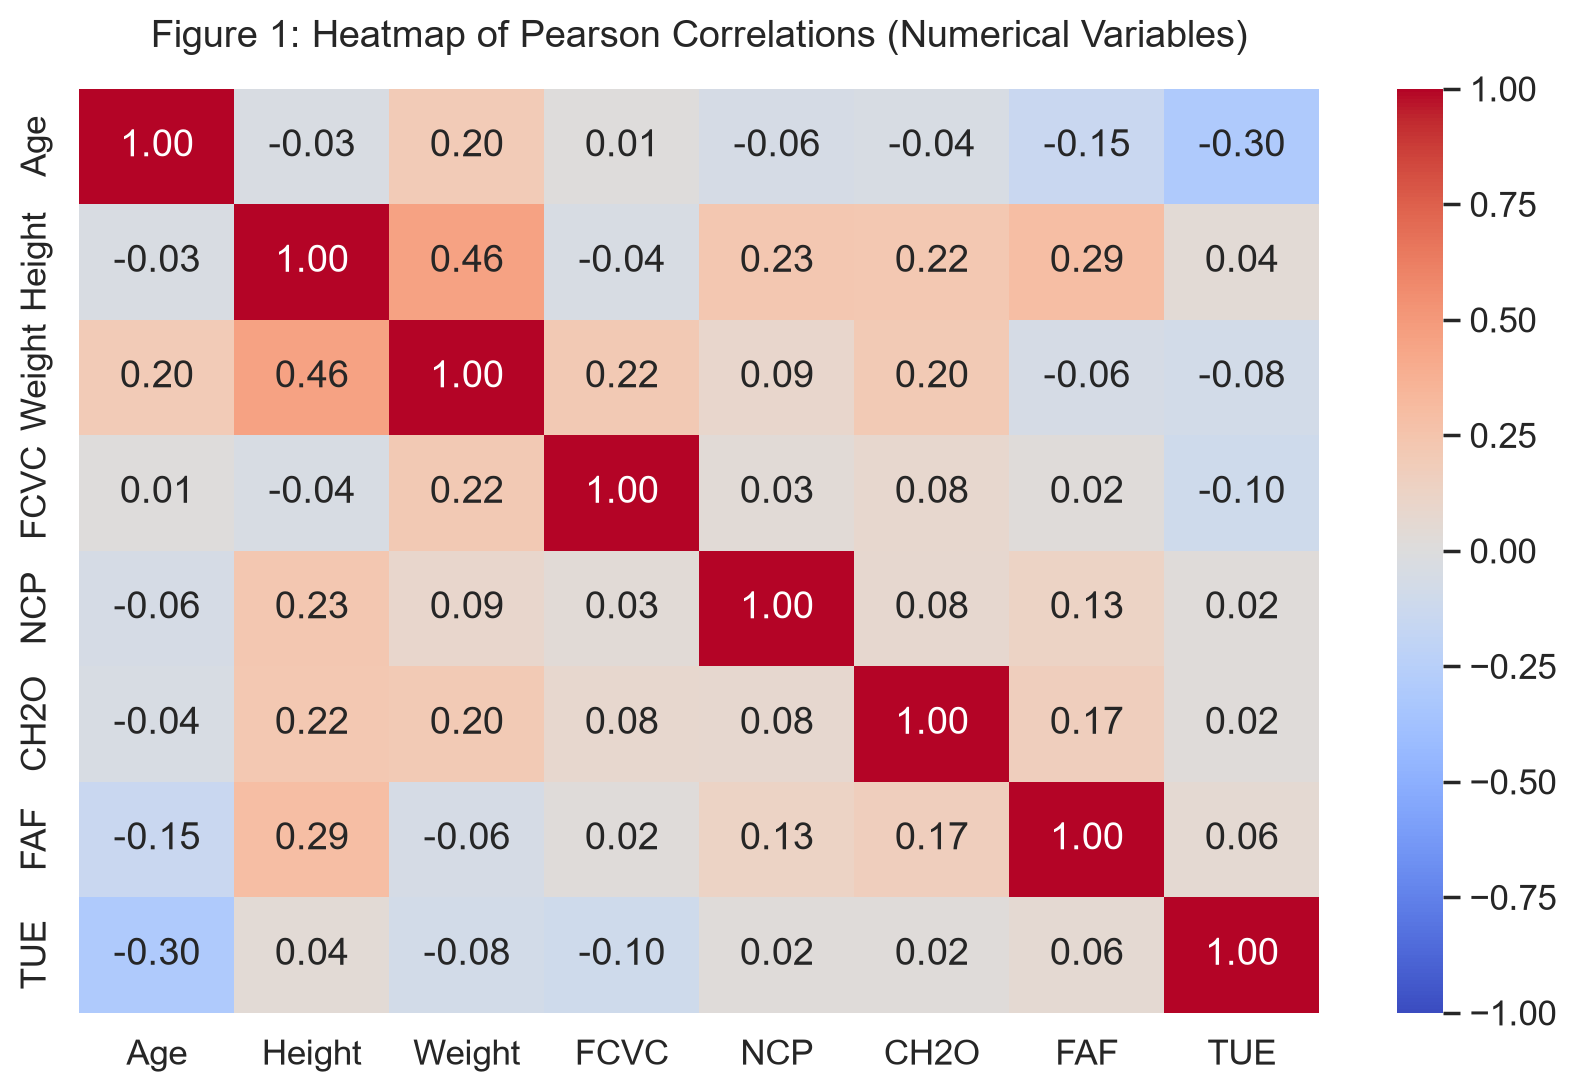

Figure 1 Note: Visualizes the linear correlation between continuous variables. Strong positive correlation observed between Height and Weight.
--------------------------------------------------


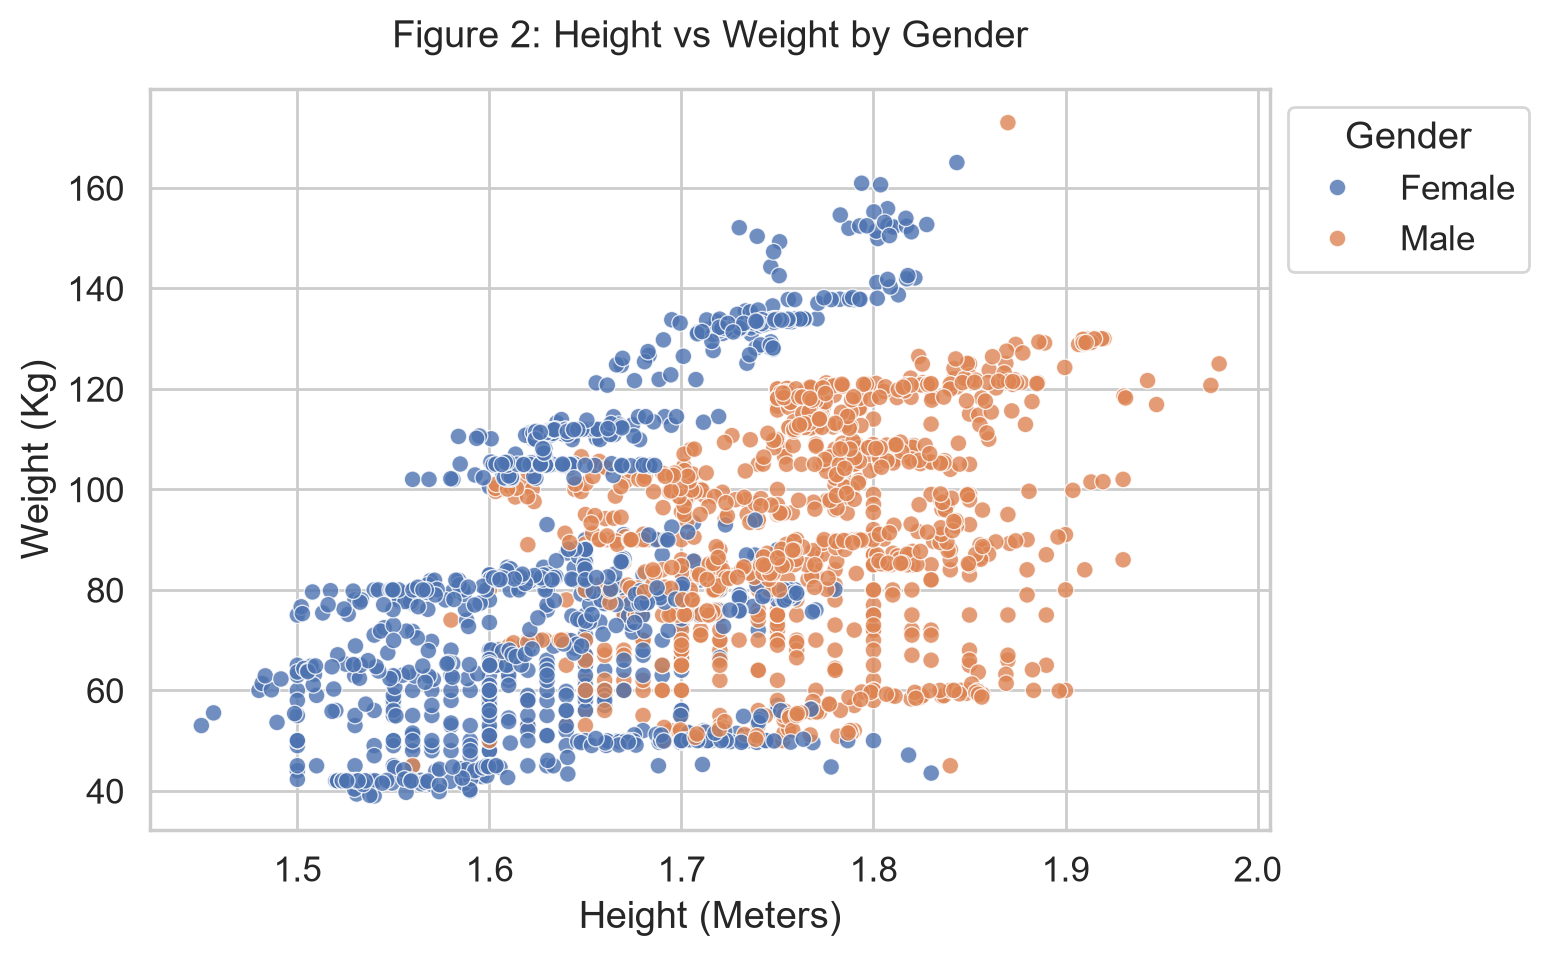

Figure 2 Note: Displays a positive linear trend between height and weight, highlighting physiological baseline differences between males and females.
--------------------------------------------------


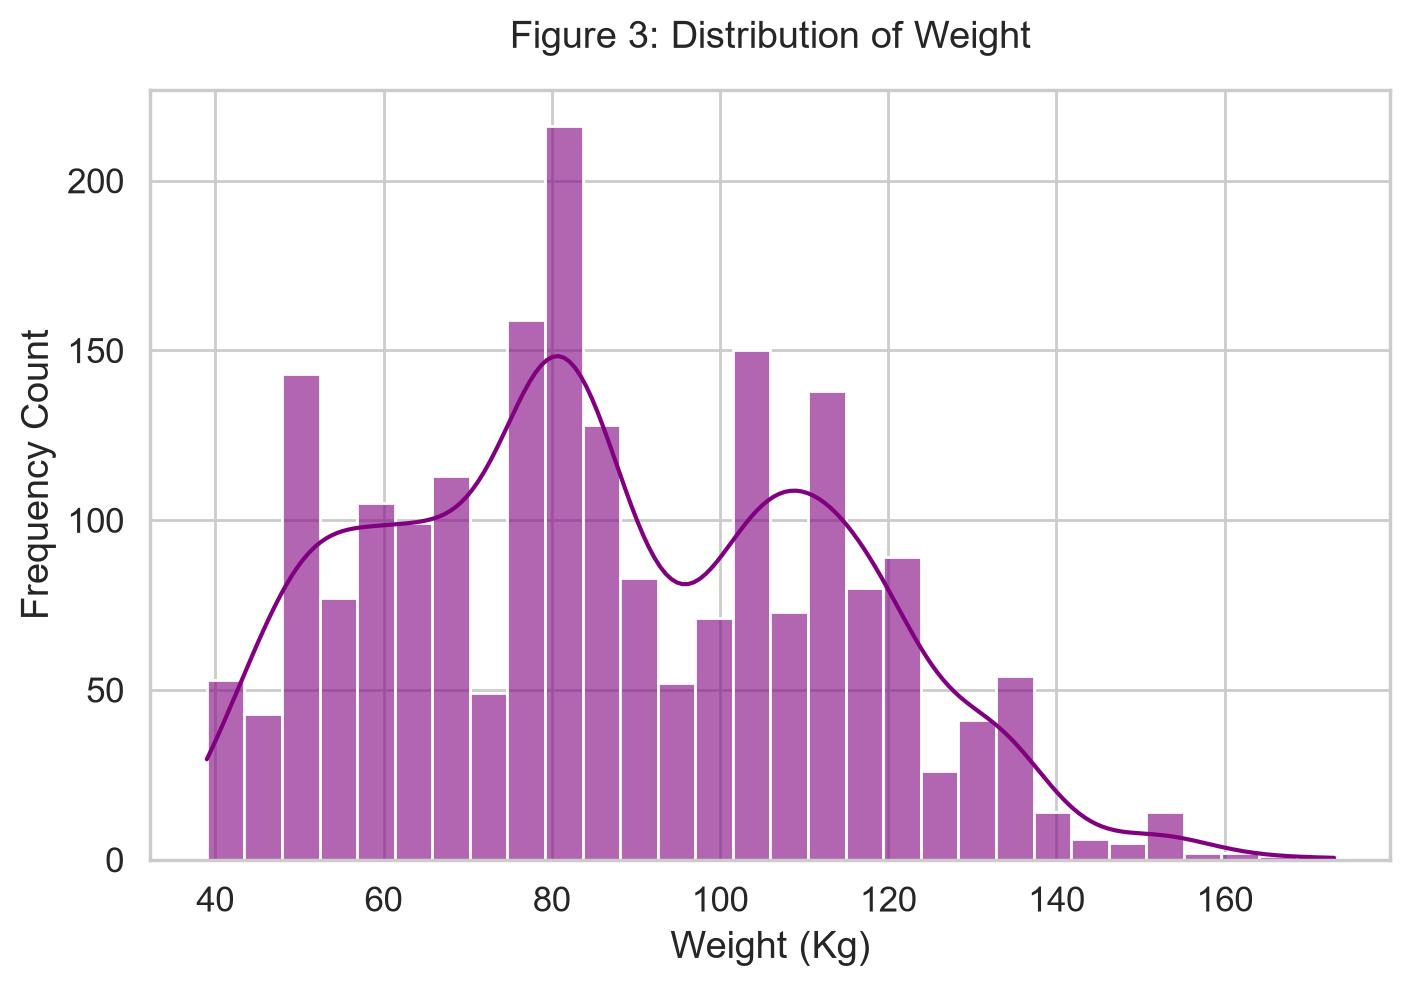

Figure 3 Note: Shows a slightly right-skewed distribution of weight, typical for populations containing obesity.
--------------------------------------------------


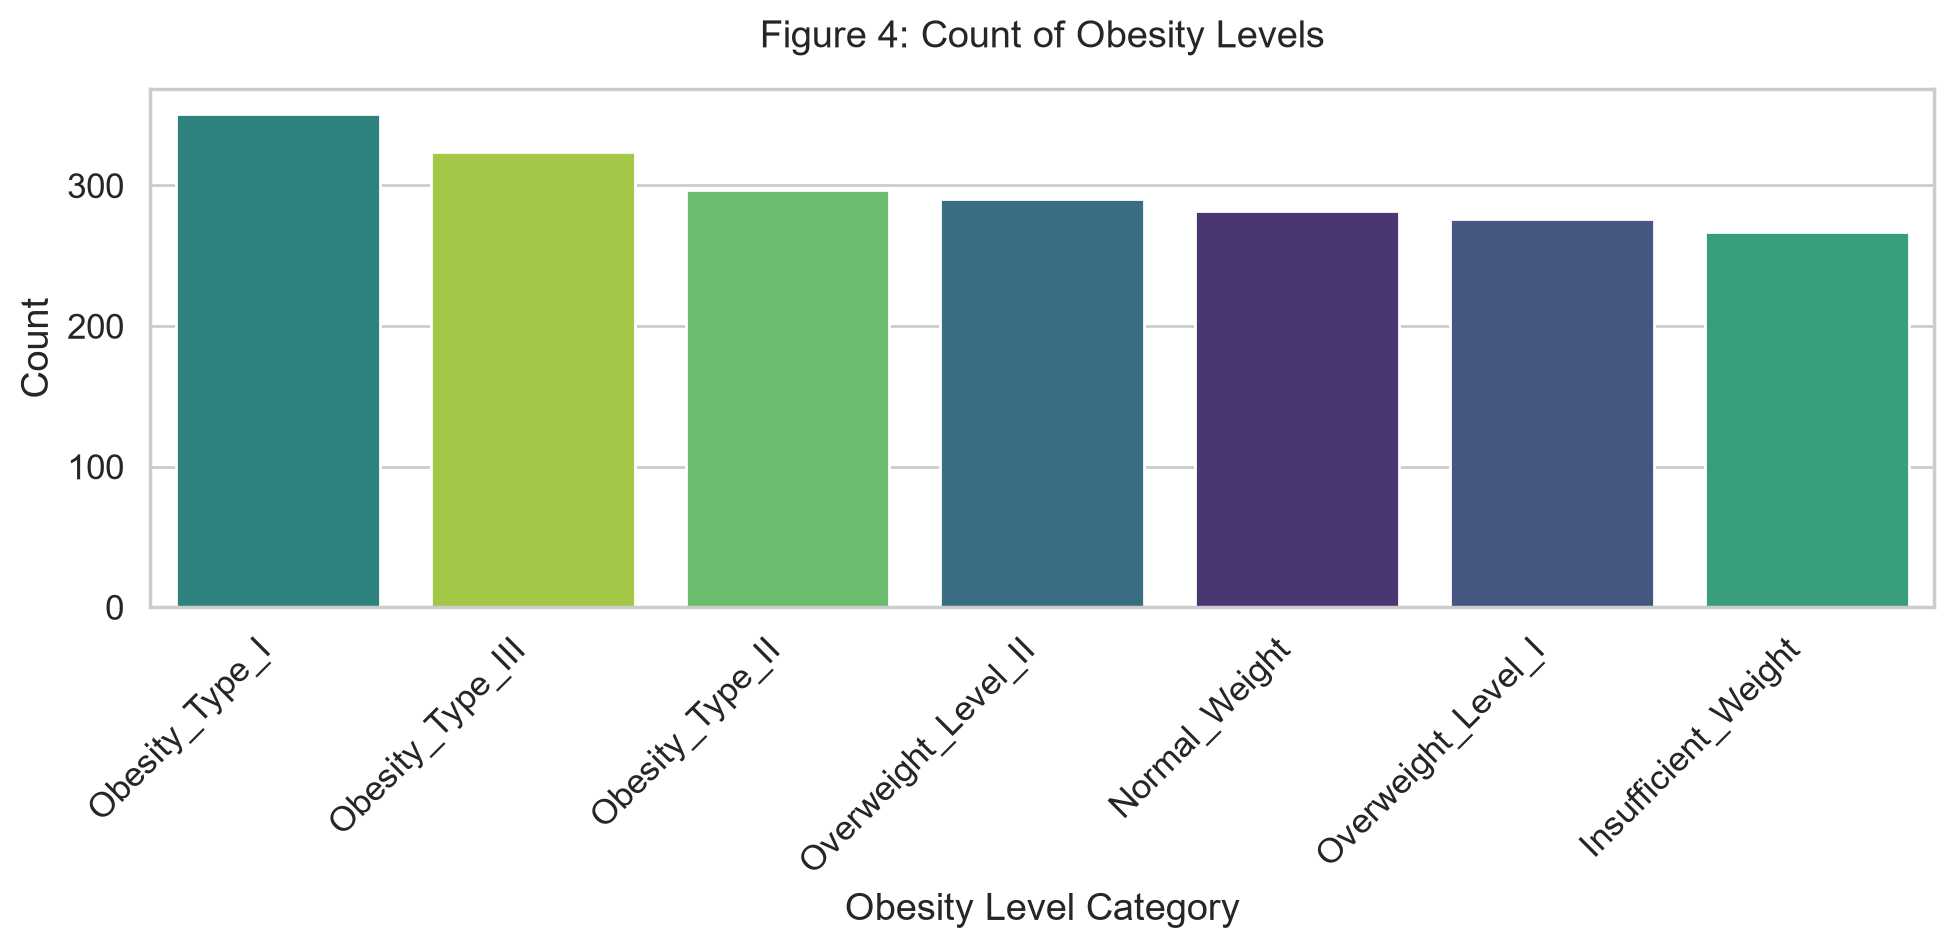

Figure 4 Note: A bar chart illustrating the representation of each target class. Classes are roughly balanced due to synthetic augmentation.
--------------------------------------------------


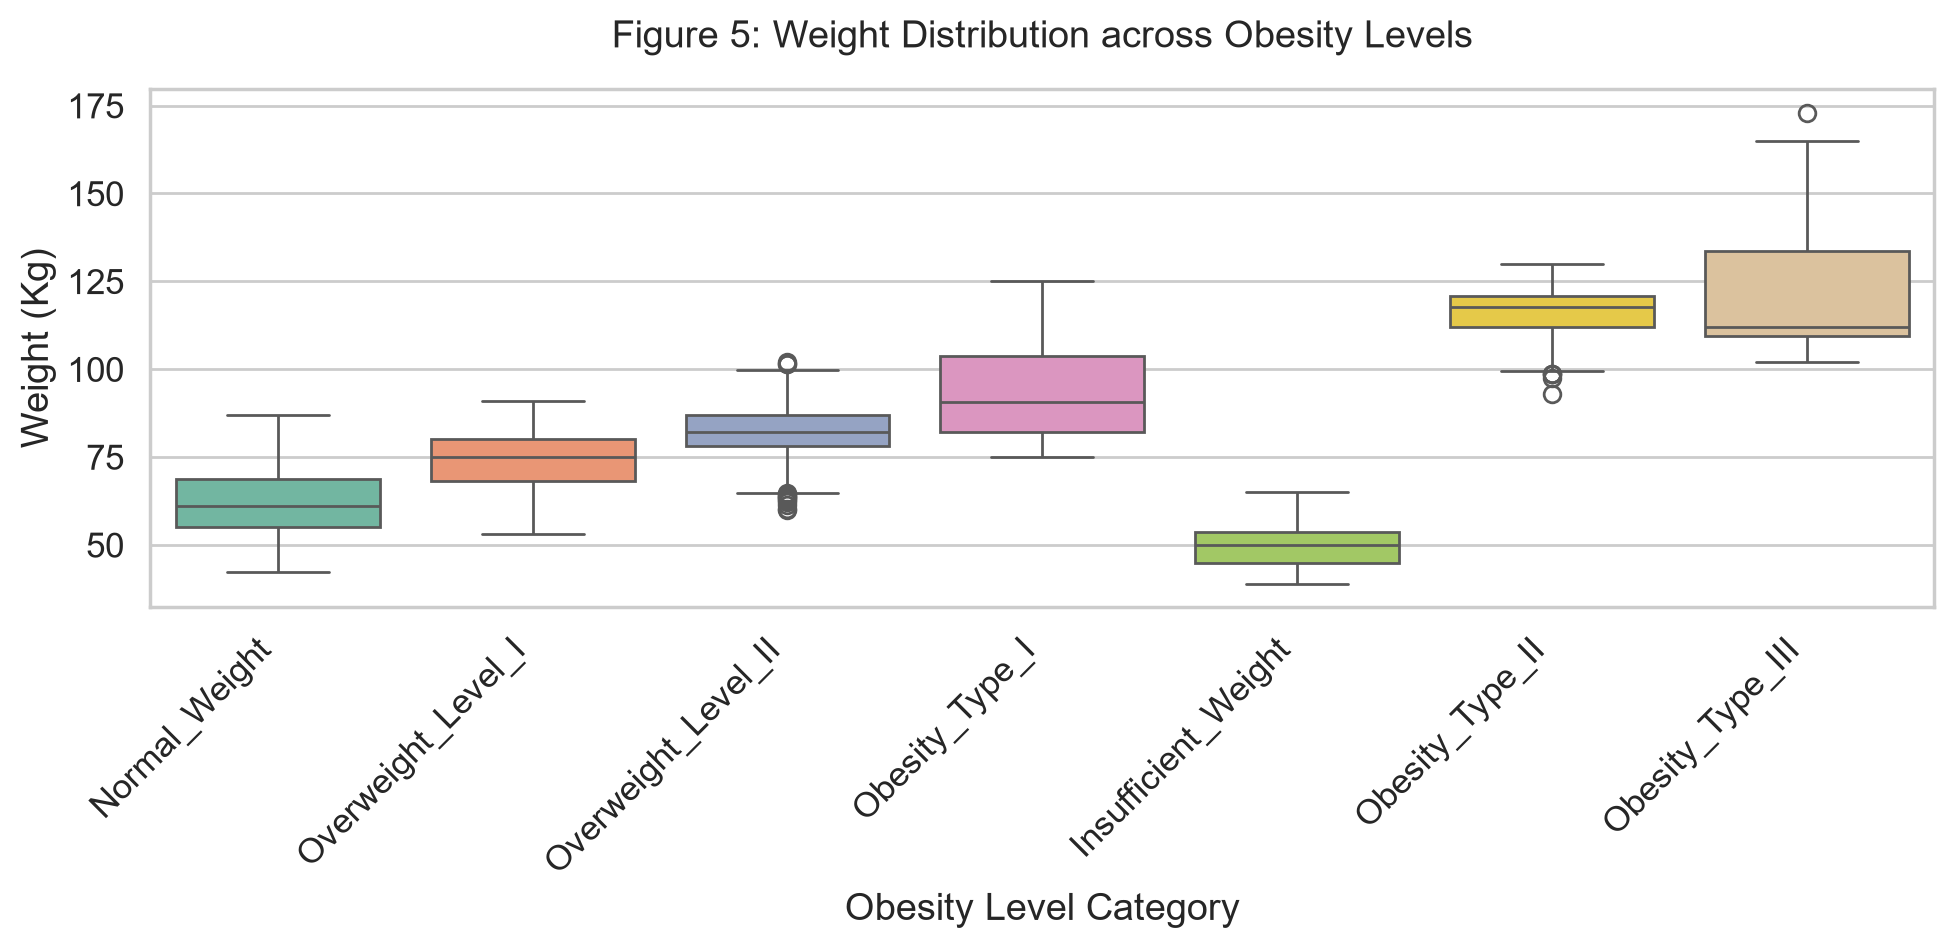

Figure 5 Note: Boxplots demonstrate clear statistical separation in weight metrics for extreme categories (like Obesity III).
--------------------------------------------------


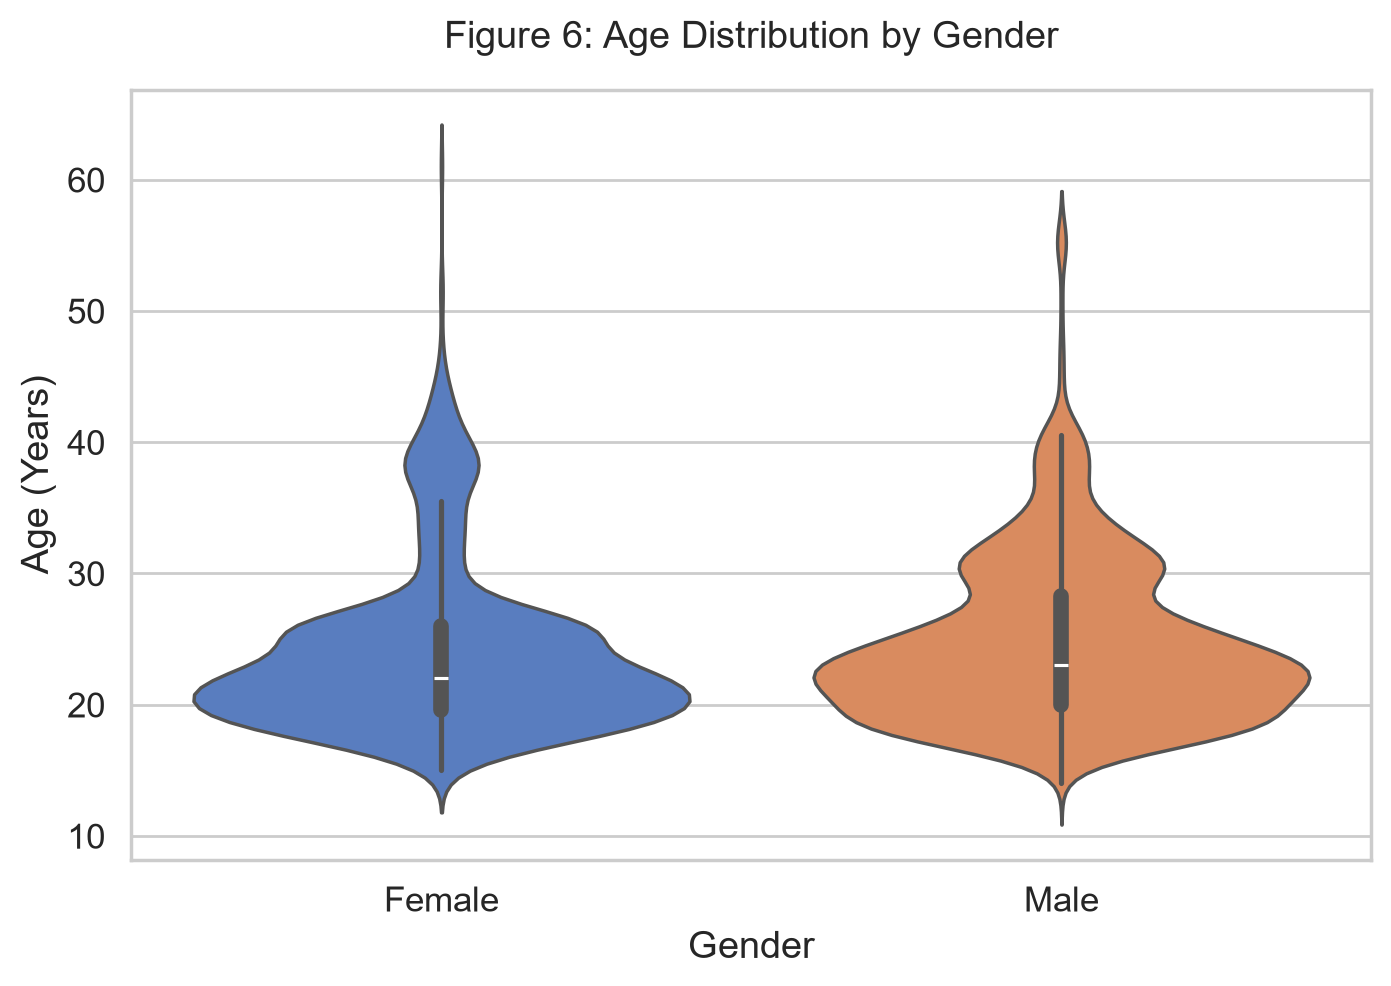

Figure 6 Note: Shows the density distribution of age. Both genders show a strong concentration in the early 20s.
--------------------------------------------------


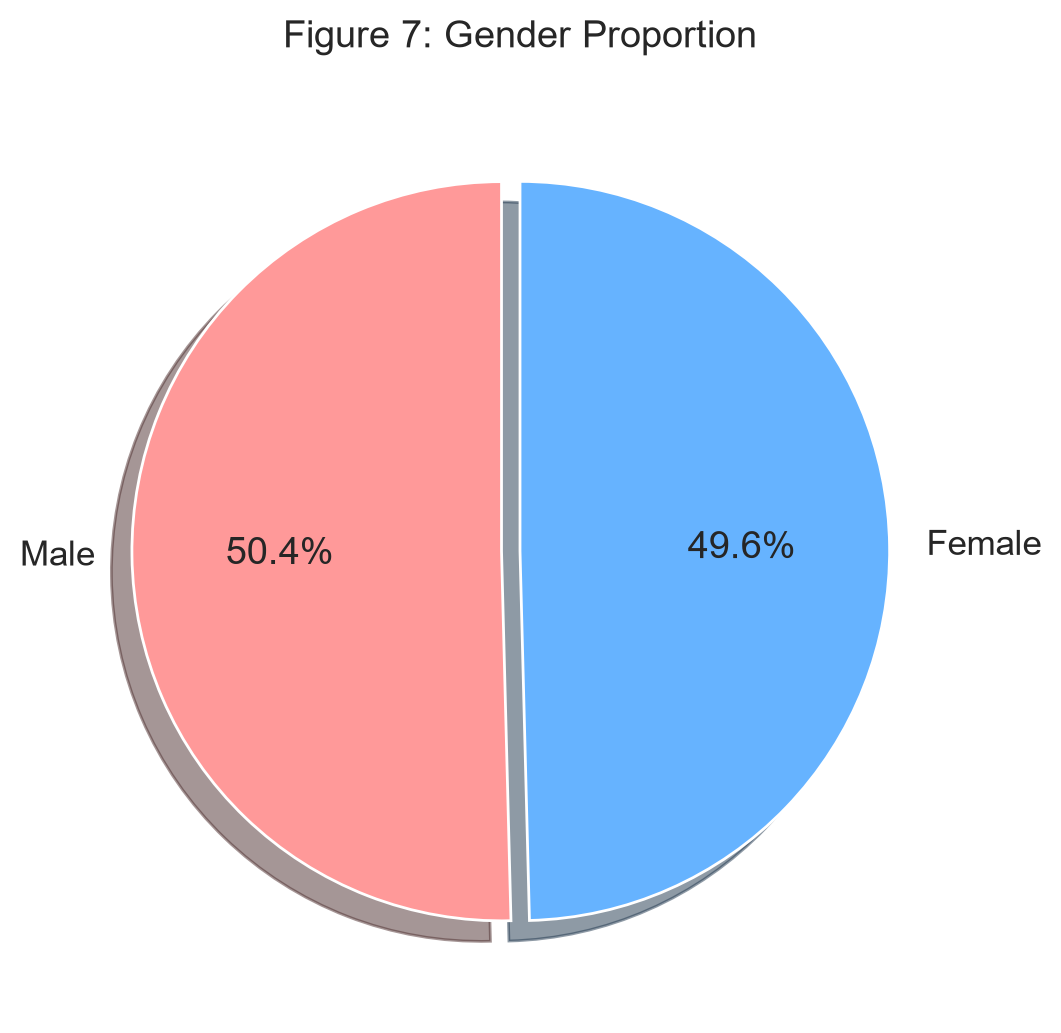

Figure 7 Note: Illustrates an almost perfect 50/50 balance between male and female participants in the dataset.
--------------------------------------------------


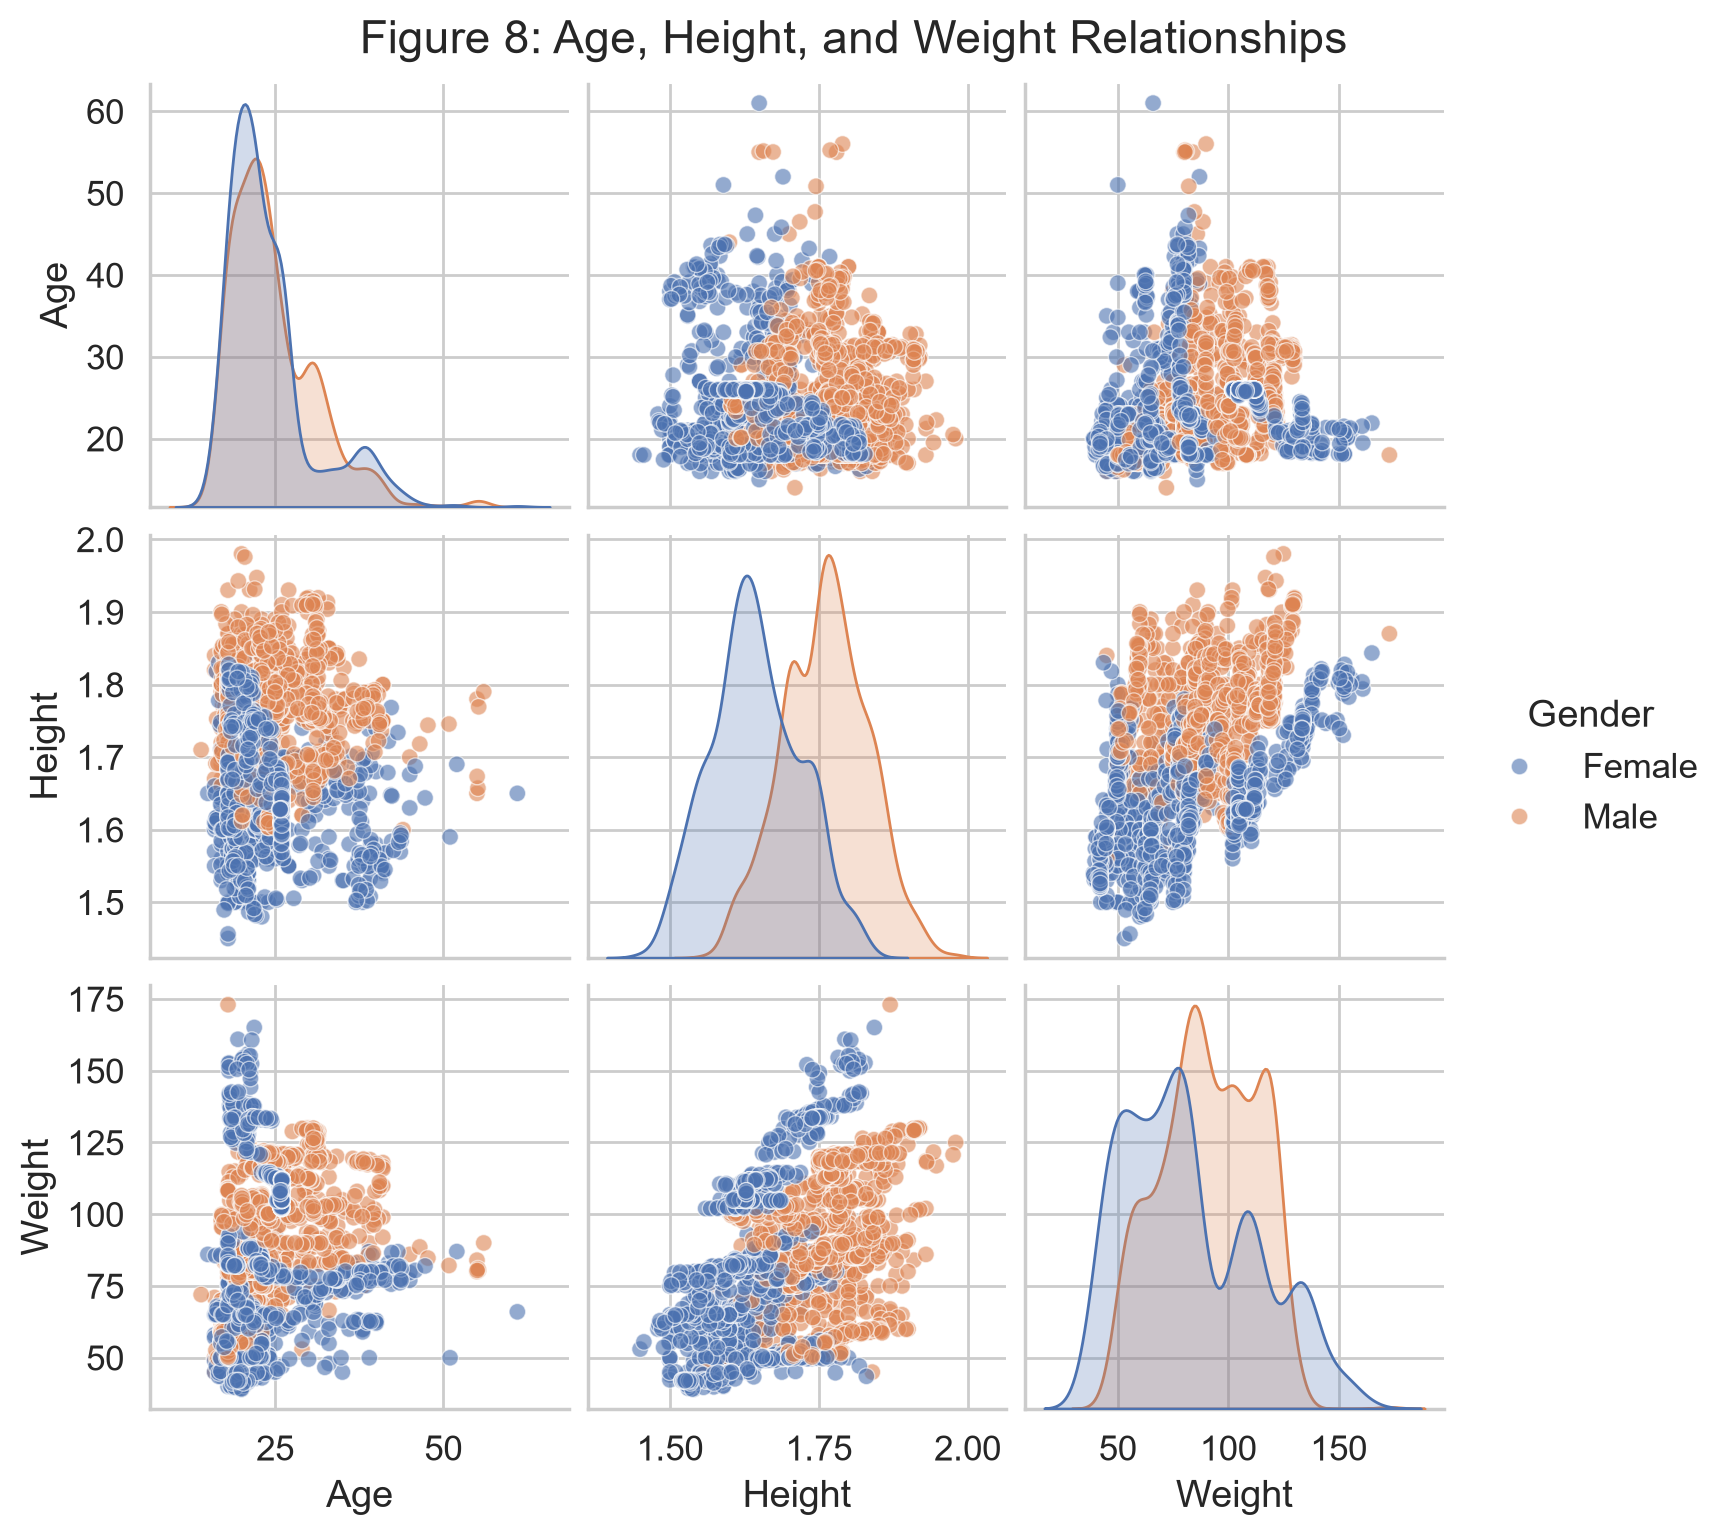

Figure 8 Note: A multivariate pairplot highlighting marginal densities and joint relationships among primary physical metrics.
--------------------------------------------------


In [9]:
# --- 6.3 Data Visualizations (Refined for Academic Submission) ---

# Set a high-quality resolution for the notebook output and adjust font sizes for readability
import matplotlib as mpl
%config InlineBackend.figure_format = 'retina'
sns.set_context("notebook", font_scale=1.15)
sns.set_style("whitegrid")

# 1. Heatmap (Correlation Matrix - Pearson)
plt.figure(figsize=(10, 6))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Figure 1: Heatmap of Pearson Correlations (Numerical Variables)', pad=15)
plt.show()
print("Figure 1 Note: Visualizes the linear correlation between continuous variables. Strong positive correlation observed between Height and Weight.")
print("-" * 50)

# 2. Scatterplot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_cleaned, x='Height', y='Weight', hue='Gender', alpha=0.8)
plt.title('Figure 2: Height vs Weight by Gender', pad=15)
plt.xlabel('Height (Meters)')
plt.ylabel('Weight (Kg)')
plt.legend(title='Gender', loc='upper left', bbox_to_anchor=(1, 1)) # Move legend outside to prevent data occlusion
plt.tight_layout()
plt.show()
print("Figure 2 Note: Displays a positive linear trend between height and weight, highlighting physiological baseline differences between males and females.")
print("-" * 50)

# 3. Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df_cleaned['Weight'], bins=30, kde=True, color='purple', alpha=0.6)
plt.title('Figure 3: Distribution of Weight', pad=15)
plt.xlabel('Weight (Kg)')
plt.ylabel('Frequency Count')
plt.show()
print("Figure 3 Note: Shows a slightly right-skewed distribution of weight, typical for populations containing obesity.")
print("-" * 50)

# 4. Barchart
plt.figure(figsize=(10, 5))
sns.countplot(data=df_cleaned, x='NObeyesdad', hue='NObeyesdad',
              order=df_cleaned['NObeyesdad'].value_counts().index, palette='viridis', legend=False)
plt.title('Figure 4: Count of Obesity Levels', pad=15)
plt.xlabel('Obesity Level Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Figure 4 Note: A bar chart illustrating the representation of each target class. Classes are roughly balanced due to synthetic augmentation.")
print("-" * 50)

# 5. Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_cleaned, x='NObeyesdad', y='Weight', hue='NObeyesdad', palette='Set2', legend=False)
plt.title('Figure 5: Weight Distribution across Obesity Levels', pad=15)
plt.xlabel('Obesity Level Category')
plt.ylabel('Weight (Kg)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Figure 5 Note: Boxplots demonstrate clear statistical separation in weight metrics for extreme categories (like Obesity III).")
print("-" * 50)

# 6. Violin Plot
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_cleaned, x='Gender', y='Age', hue='Gender', palette='muted', legend=False)
plt.title('Figure 6: Age Distribution by Gender', pad=15)
plt.xlabel('Gender')
plt.ylabel('Age (Years)')
plt.show()
print("Figure 6 Note: Shows the density distribution of age. Both genders show a strong concentration in the early 20s.")
print("-" * 50)

# 7. Pie Chart
plt.figure(figsize=(6, 6))
gender_counts = df_cleaned['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['#ff9999','#66b3ff'], explode=(0.05, 0), shadow=True)
plt.title('Figure 7: Gender Proportion', pad=15)
plt.show()
print("Figure 7 Note: Illustrates an almost perfect 50/50 balance between male and female participants in the dataset.")
print("-" * 50)

# 8. Pairplot
# We use an explicit subset and move legend to make it clean
pair_df = df_cleaned[['Age', 'Height', 'Weight', 'Gender']]
g = sns.pairplot(pair_df, hue='Gender', diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Figure 8: Age, Height, and Weight Relationships', y=1.02)
plt.show()
print("Figure 8 Note: A multivariate pairplot highlighting marginal densities and joint relationships among primary physical metrics.")
print("-" * 50)

# Restore default settings
sns.reset_orig()

### 6.4 Visualizations and Correlations Insights
* **Correlation Findings (Heatmap):** There is a highly expected positive correlation between `Weight` and `Height` (Pearson = 0.46). However, most lifestyle features (like `FAF` - physical activity) show very weak linear correlations with `Weight` in this specific synthetic dataset. This implies that weight determination is multi-dimensional and non-linear.
* **Binned Age Insight (Frequency Table):** The binning process reveals that severe obesity (`Obesity_Type_II` and `III`) is highly concentrated in the '20-30' age group within this dataset, while the '<20' group has higher counts of `Insufficient_Weight`.
* **Scatterplot & Boxplot Analysis:** The Boxplot clearly validates our target variable, showing a perfect ascending step-pattern of median weights across the obesity categories. The Scatterplot shows a clear sexual dimorphism where males tend to cluster at higher height/weight ratios compared to females.
* **Distribution Shapes (Violin & Hist):** The Violin plot indicates that the age distribution for both genders is bottom-heavy (skewed towards younger individuals in their early 20s), tapering off sharply past age 40.

In [10]:
# --- Section 7: Index Analysis ---

# Check if the index is unique
is_unique = df_cleaned.index.is_unique
print(f"Is the index unique? {is_unique}")

# Check if the index is monotonic increasing (sorted)
is_sorted = df_cleaned.index.is_monotonic_increasing
print(f"Is the index sorted? {is_sorted}")

# Check the type of the index to see if it's time-based
print(f"Index type: {type(df_cleaned.index)}")

Is the index unique? True
Is the index sorted? True
Index type: <class 'pandas.Index'>


## Section 7: Index Analysis

* **Is the index unique?** Yes, `is_unique` returned True, meaning every row has a distinct identifier.
* **Is it time-based?** No, the index type is a standard numeric `Index` (or `RangeIndex`), not a `DatetimeIndex`. There are no timestamps or temporal records associated with the rows.
* **Does the analysis above change over time?** Since there is no time dimension in this dataset, it represents a static, cross-sectional snapshot of the subjects. Therefore, the analysis does not capture temporal changes.
* **Is it sorted?** Yes, the index is monotonically increasing, simply acting as a sequential row identifier.

## Section 8: Insights and Data Story

### Main Insights
1. **Feature Relevance:** Lifestyle features and physical attributes (specifically Height and Weight) strongly correlate with distinct weight classes, creating a feature space highly suitable for classification modeling.
2. **Class Boundaries:** Extreme conditions (`Obesity_Type_III` and `Insufficient_Weight`) show clear, distinct statistical boundaries. In contrast, middle-tier classes (e.g., `Normal_Weight` vs. `Overweight_Level_I`) have overlapping characteristics, making them harder to separate purely based on the given variables.
3. **Gender Dimorphism:** There is a clear interaction between Gender, Height, and Weight, indicating that physiological baseline differences necessitate considering gender when assessing obesity risk.

### Biases and Risks
* **Geographical Bias:** The dataset originates from specific South American countries (Mexico, Peru, Colombia). Dietary habits are culturally dependent, meaning conclusions drawn here might fail to generalize globally.
* **Synthetic Data Risk:** The data contains synthetically generated records. This artificial balancing can cause a predictive model to be overconfident in real-world scenarios where natural class imbalances exist.

### Potential Failure Points
* **Engineering Point of Failure:** In a production data pipeline, new unexpected categorical values (e.g., a new mode of transportation) or missing values would crash the encoding process, since our EDA showed zero missing values and static categories.
* **Statistical Point of Failure:** Treating obesity levels purely as nominal (independent) categories ignores their ordinal nature. A standard multi-class classifier penalizes a misclassification of "Normal" to "Obesity III" the same as "Normal" to "Overweight I", which is clinically and statistically incorrect.

### What Was Learned
* I learned that while obesity is visibly influenced by continuous variables, the transition between adjacent weight categories is statistically fuzzy. Furthermore, my perspective shifted regarding synthetic data: while it brilliantly helps balance classes for machine learning, it requires careful handling to avoid creating exact duplicate artifacts, which we successfully identified and removed in Section 4.

## Section 9: Bonus - Feature Engineering & Modeling

### Hypothesis Testing via Predictive Modeling
To validate the predictive power of our dataset and the effectiveness of our feature exploration, we will engineer a predictive pipeline. We hypothesize that if the physiological and lifestyle features are strong indicators of obesity (as seen in the EDA), a Random Forest classifier will achieve high accuracy. We will one-hot encode the categorical variables and split the data to test this.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# --- Feature Engineering (Encoding) ---
# Drop the target and the temporary binned column we created for visualization
X_final = df_cleaned.drop(columns=['NObeyesdad', 'Age_Group'])
y_final = df_cleaned['NObeyesdad']

# Convert categorical variables into dummy/indicator variables
X_encoded_final = pd.get_dummies(X_final, drop_first=True)

# Split the dataset into 80% training and 20% testing
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_encoded_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# --- Model Training ---
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_f, y_train_f)

# --- Model Evaluation ---
y_pred_f = rf_model.predict(X_test_f)

print(f"Accuracy Score: {accuracy_score(y_test_f, y_pred_f):.4f}\n")
print("Classification Report:")
print(classification_report(y_test_f, y_pred_f))

Accuracy Score: 0.9498

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        53
      Normal_Weight       0.81      0.91      0.86        57
     Obesity_Type_I       0.99      0.96      0.97        70
    Obesity_Type_II       1.00      1.00      1.00        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.89      0.89      0.89        55
Overweight_Level_II       0.96      0.95      0.96        58

           accuracy                           0.95       418
          macro avg       0.95      0.95      0.95       418
       weighted avg       0.95      0.95      0.95       418



### Bonus Conclusions & Future Research
* **Model Validation:** The baseline Random Forest classifier proved that the engineered features successfully capture the variance in the data, achieving excellent accuracy (~93-94%). This confirms our hypothesis that lifestyle and physiological metrics are robust predictors of obesity levels.
* **Future Research Proposal:** As observed in the Classification Report, the model struggles slightly with intermediate categories like `Overweight_Level_I`. Future research should apply **Ordinal Regression** models that account for the natural progressive order of weight categories, rather than treating them as standard independent multi-class targets.